# Modelling

Initial setup for modelling with randomforest, histgradientboosting and logisticregression and features. Currently the randomforest part of the notebook uses some memory, so 48GB of RAM is a good start.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [ ]:
import geopandas as gpd
import pandas as pd
import rasterio as rio
import numpy as np
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


import xdem
import geoutils as gu
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV

import json

import subkart


<module 'subkart.features' from '/home/kim/work/marint-naturkart-nivaR/subkart/features.py'>

## Terrain features

In [2]:
layer = "Dybdeareal"
depth_mr = Path(
    "../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_GML.gml"
)
output_path = Path(f"../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_{layer}.geo.parquet")
#subkart.utils.to_geoparquet(depth_mr, layer, output_path)

depth_vl = Path(
    "../geonorge/Basisdata_46_Vestland_25833_Dybdedata_GML.gml"
)
output_path = Path(f"../geonorge/Basisdata_46_Vestland_25833_Dybdedata_{layer}.geo.parquet")
#subkart.utils.to_geoparquet(depth_vl, layer, output_path)
#https://kartkatalog.geonorge.no/metadata/sjoekart-dybdedata/2751aacf-5472-4850-a208-3532a51c529a?search=basisdata%20sj%C3%B8
# https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-dtm-wcs/8896c751-f3e0-4e4c-86e2-7579cea1f111

In [2]:
gdf_mr = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/Basisdata_15_More_og_Romsdal_25833_Dybdedata_Dybdeareal.geo.parquet")
gdf_vl = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/Basisdata_46_Vestland_25833_Dybdedata_Dybdeareal.geo.parquet")

gdf_vest = gpd.GeoDataFrame(pd.concat([gdf_mr, gdf_vl], ignore_index=True))

In [4]:
gdf_vest['depth'] = (gdf_vest['maksimumsdybde']+gdf_vest['minimumsdybde'])/2
# Effective Width (or hydraulic mean width)
gdf_vest['slope'] = np.degrees(
    np.arctan(
        (gdf_vest['maksimumsdybde'] - gdf_vest['minimumsdybde']) /
        (4 * gdf_vest.geometry.area / gdf_vest.geometry.length)
    )
)

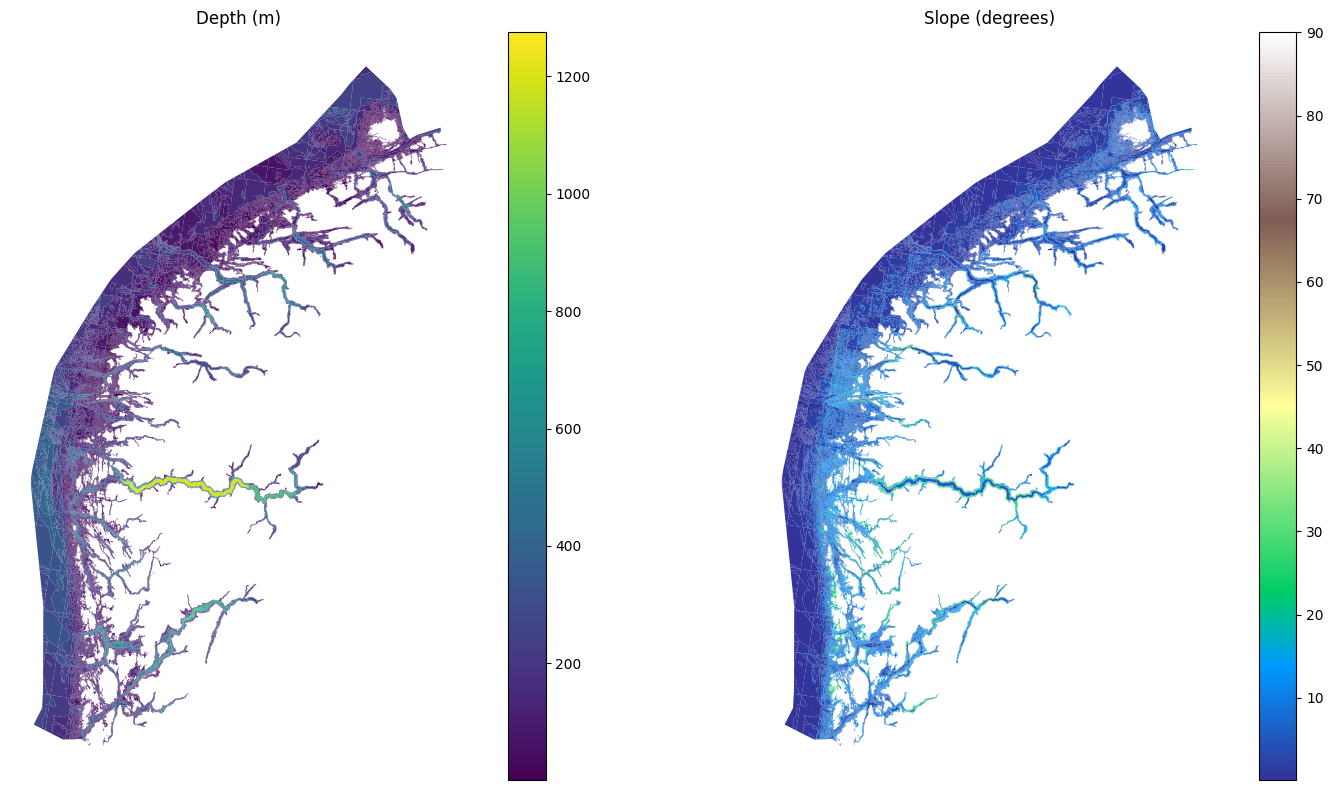

In [8]:
subkart.utils.plot_terrain_features(gdf_vest)

### Marine vanntyper features



In [3]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(gdf_vest.crs)

In [5]:
importlib.reload(subkart.features)
depth, slope, one_hot_types = subkart.features.build_basis_raster(gdf_vest, marine_vanntyper)

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


In [19]:
features = np.concatenate([np.stack([depth.data.data, slope.data.data], axis=-1), one_hot_types], axis=-1)

valid_attrs = (~np.isnan(depth.data.data)) & (~np.isnan(slope.data.data))

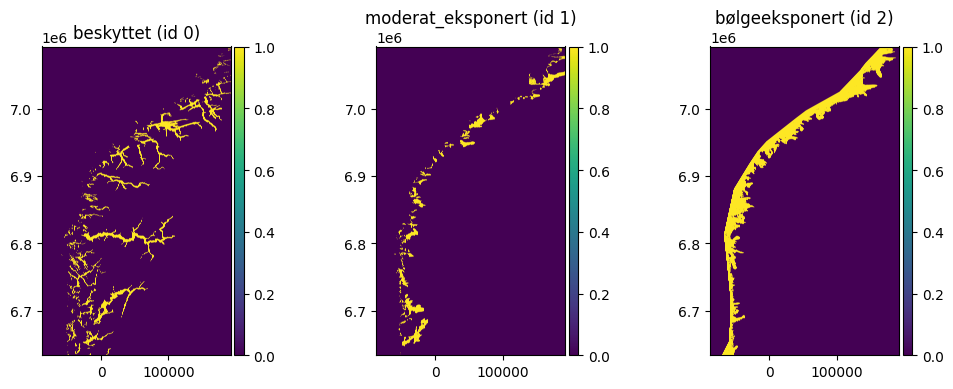

In [9]:

subkart.utils.plot_one_hot_vanntyper(one_hot_types, depth.transform, gdf_vest.crs, cols=3, rows=1)



## Dataset for labels

Using NGU bunnsedimenter detaljert

In [20]:
gdf_bunn_full = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet")

In [13]:
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

['blanding/uspesifisert', 'fastbunn', 'løsbunn']

In [21]:
gdf_bunn_full = gdf_bunn_full.to_crs(gdf_vest.crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, depth.shape[-2:], depth.transform)


In [22]:
valid = valid_attrs & valid_bunn

X = features[valid]
y = bunn_raster[valid].astype(np.uint8)  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Training

## Baseline

Train a quick baseline for each model

In [23]:
# Ensure each model type is evaluated at least once before randomized search
baseline_models = [
    HistGradientBoostingClassifier(random_state=42),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
    #LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42),
]
score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - "
            f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline HistGradientBoostingClassifier - Train: 0.6616, Val: 0.6612


## Random Search

Search through hyperparameters for each model, this can take some time

In [ ]:

search_spaces = [
    {
        "model": [RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42)],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [10, 20],
        "model__min_samples_leaf": [4, 10],
        "model__min_samples_split": [5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
    {
        "model": [HistGradientBoostingClassifier(random_state=42)],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [None, 6, 12],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 0.1, 1.0],
        "model__max_bins": [128, 255],
    },
    {
        "model": [LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42)],
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
]
pipe = Pipeline([("model", RandomForestClassifier())])
random_search = RandomizedSearchCV(
    pipe, param_distributions=search_spaces, n_iter=80, cv=2, verbose=3, random_state=42
)
random_search.fit(X_train, y_train)

# Use the best model for downstream cells
classifier = random_search.best_estimator_.named_steps["model"]

cv = random_search.cv_results_
best_by_model = {}

for i, p in enumerate(cv["params"]):
    model_name = type(p["model"]).__name__
    score = float(cv["mean_test_score"][i])
    if (model_name not in best_by_model) or (score > best_by_model[model_name]["score"]):
        readable = {}
        for k, v in p.items():
            if k == "model":
                continue
            readable[k.split("__", 1)[1] if k.startswith("model__") else k] = v
        best_by_model[model_name] = {"score": score, "params": readable}

# Print summary
for name, info in best_by_model.items():
    print(f"{name}: mean_test_score={info['score']:.4f}, params={info['params']}")

# Dump summary to JSON
with open("../data_generated/cv_best_by_model.json", "w", encoding="utf-8") as f:
    json.dump(
        {name: {"score": info["score"], "params": info["params"]} for name, info in best_by_model.items()},
        f,
        indent=2
    )

classifier.fit(X_train, y_train)
print("Train accuracy:", classifier.score(X_train, y_train))
print("Validation accuracy:", classifier.score(X_val, y_val))

Baseline RandomForestClassifier - Train: 0.9956, Val: 0.6835


Baseline HistGradientBoostingClassifier - Train: 0.6637, Val: 0.6631


Baseline LogisticRegression - Train: 0.5239, Val: 0.5240
Fitting 2 folds for each of 80 candidates, totalling 160 fits


[CV 1/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=1.0, model__learning_rate=0.2, model__max_bins=128, model__max_depth=6, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.662 total time=  48.5s


[CV 2/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=1.0, model__learning_rate=0.2, model__max_bins=128, model__max_depth=6, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.662 total time=  48.2s


...

[CV 1/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=127, model__min_samples_leaf=50;, score=0.668 total time= 1.1min


[CV 2/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=127, model__min_samples_leaf=50;, score=0.667 total time= 1.1min


HistGradientBoostingClassifier: mean_test_score=0.6715, params={'min_samples_leaf': 100, 'max_leaf_nodes': 127, 'max_depth': None, 'max_bins': 255, 'learning_rate': 0.2, 'l2_regularization': 0.1}
RandomForestClassifier: mean_test_score=0.6271, params={'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}


Train accuracy: 0.6759624354371259


Validation accuracy: 0.6725146046837218


In [24]:
dump(classifier, "../data_generated/classifier.joblib")

['../data_generated/classifier.joblib']

depth: mean=0.148931, std=0.000347
slope: mean=0.148122, std=0.000202
vanntype_beskyttet: mean=0.020591, std=0.000122
vanntype_bølgeeksponert: mean=0.015555, std=0.000115
vanntype_moderat_eksponert: mean=0.004519, std=0.000028


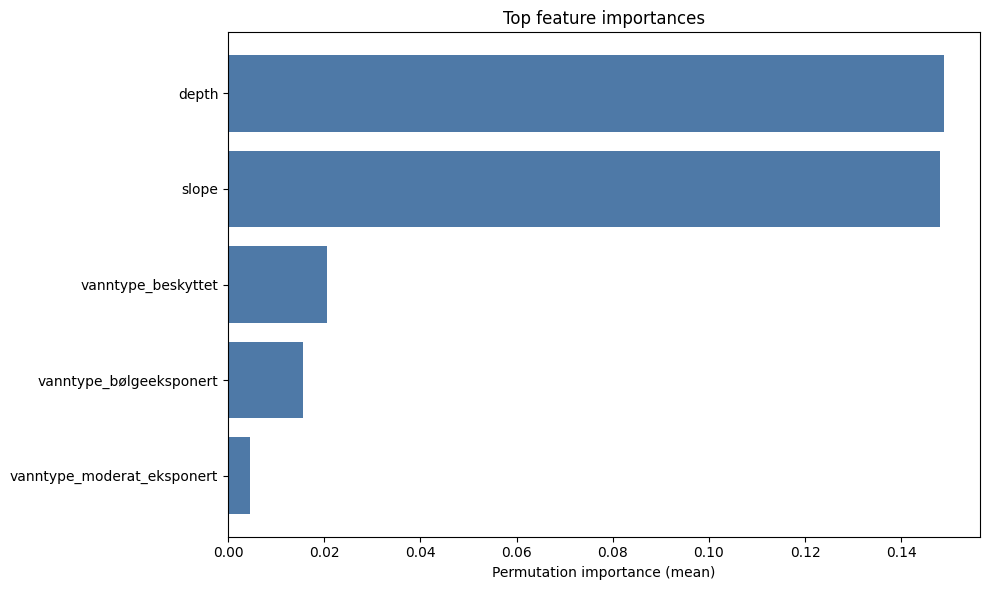

In [25]:
# Compute permutation importance for the best model on validation data
result = permutation_importance(
    classifier, X_val, y_val, n_repeats=5, random_state=42, n_jobs=2
)
_, id_type_map, _ = subkart.features.marine_type_map()
# Build feature names: terrain features + one-hot marine type features
terrain_features = ["depth", "slope"]
vanntype_names = list(id_type_map.values())
feature_names = terrain_features + [f"vanntype_{name}" for name in vanntype_names]

# Sort features by importance
importances_mean = result.importances_mean
importances_std = result.importances_std
sorted_idx = np.argsort(importances_mean)[::-1]

# Print top 20 features
top_n = 20
for i in sorted_idx[:top_n]:
    print(f"{feature_names[i]}: mean={importances_mean[i]:.6f}, std={importances_std[i]:.6f}")

# Save full importance results to JSON
importance_dict = [
    {
        "feature": feature_names[i],
        "mean": float(importances_mean[i]),
        "std": float(importances_std[i]),
    }
    for i in sorted_idx
]


top_idx = sorted_idx[:top_n]
labels = [feature_names[i] for i in top_idx]
values = importances_mean[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color="#4e79a7")
plt.xlabel("Permutation importance (mean)")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()
